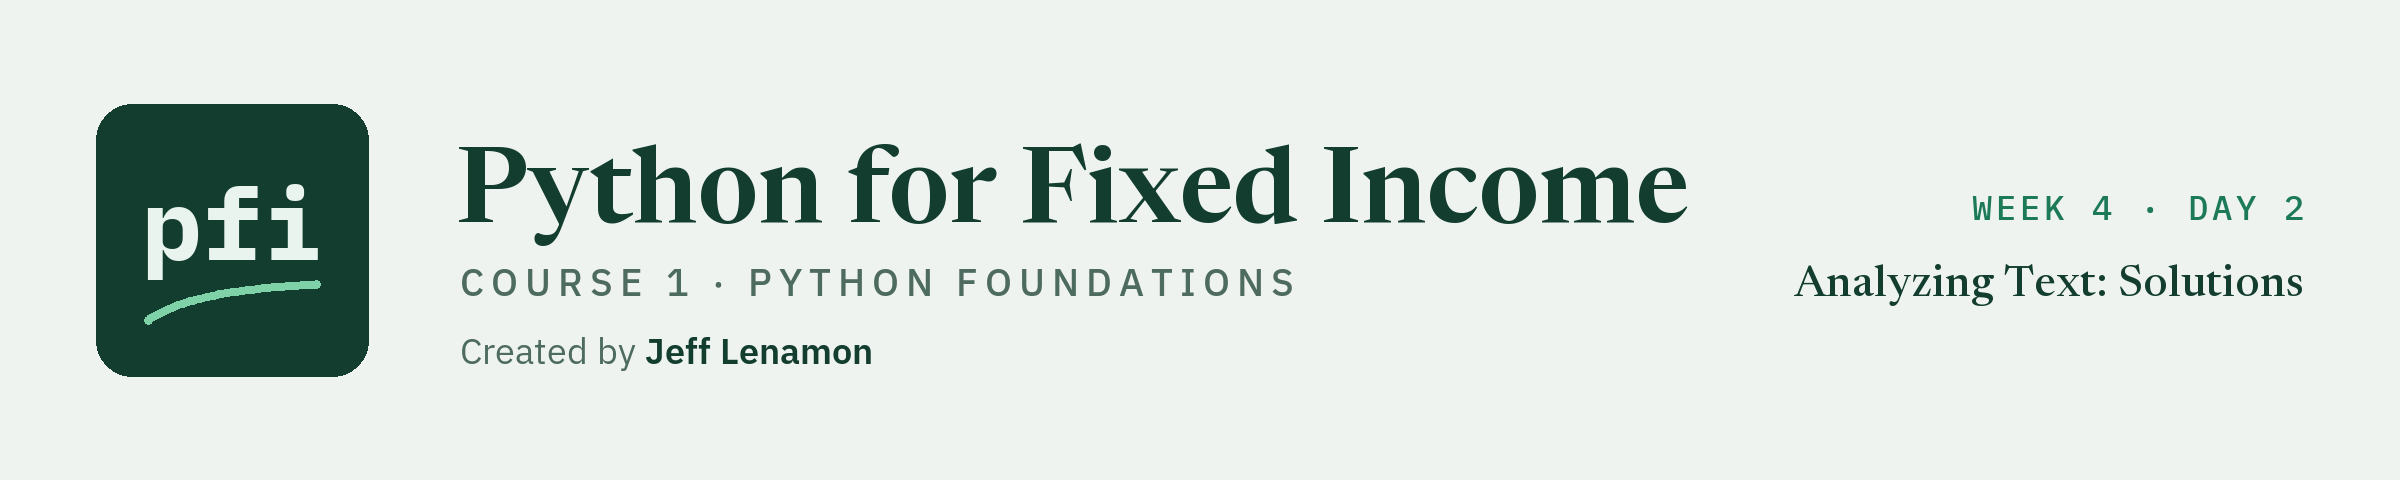

# Analyzing Text - Solutions

Week 4. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week4/day2/17_analyzing_text_solutions.ipynb)

**The data.** The text is real and public. The only portfolio data is in exercises 5 to 8, which use bond descriptions and identifiers typed from the course's synthetic holdings file.

* Source: Board of Governors of the Federal Reserve System, Federal Open Market Committee statements, federalreserve.gov. Each statement was downloaded from its own press release page, which is linked from the calendar page https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm. Retrieved on 2026-10-03.
* Reuse: the Board's website says, at https://www.federalreserve.gov/disclaimer.htm, "Unless otherwise indicated, information on Board's website is in the public domain and may be copied and distributed without permission. Please cite to the Board as the source of the information."
* The text in the file is exactly as published. The only change made when the file was built was to white space: one space between words, and one line break between paragraphs.

## Exercises

Exercises 1 to 3 use a second statement, the one dated 2022-09-21, stored as `other`. Exercise 4 and the AI check, exercise 9, use the whole table. Exercises 5 to 8 use bond descriptions and identifiers typed from the course's synthetic holdings file, and exercise 8 asks you to write a function. Every answer is a count, a figure, or a piece of text taken from a file. None is a reading of what a statement means.

Each exercise below is answered in full, and the check cell after it prints the result.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, defines `clean()` as in the lesson, loads nltk's stopword list as `stop_words`, and loads a fresh `statements`. It prints the shape of the table, (46, 3), the number of stopwords, 198, and the type of `other`.

In [1]:
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ...:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, list):
        # a list of values: the same values in the same order
        correct = list(answer) == expected
    elif isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


def clean(text):
    # the four cleaning steps of the lesson: lower case, letters only, single spaces, tokens
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split(' ')


# nltk's English stopword list, downloaded once
ready = nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

stop_words = stopwords.words('english')

# a fresh copy of the statements. In Colab the file is read from GitHub.
if os.path.exists('../../../data/fomc_statements.csv'):
    data_file = '../../../data/fomc_statements.csv'
else:
    data_file = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/fomc_statements.csv'

statements = pd.read_csv(data_file)

# the statement the first three exercises use
other = statements.loc[statements['date'] == '2022-09-21', 'text'].iloc[0]

print(statements.shape)
print(len(stop_words))
print(type(other))

(46, 3)
198
<class 'str'>


### Exercise 1

Q. For the statement dated 2022-09-21, `other`: how many characters does it have, how many words by `split()`, and how many times does `inflation` appear when capitals are ignored? Store the answers in **ex1_characters**, **ex1_words**, and **ex1_inflation**.

In [2]:
ex1_characters = len(other)
ex1_words = len(other.split())

# lower case first, so that Inflation at the start of a sentence is counted
ex1_inflation = other.lower().count('inflation')

print('Characters:', ex1_characters)
print('Words:', ex1_words)
print('inflation, capitals ignored:', ex1_inflation)
print('inflation, as typed:', other.count('inflation'), ' Inflation:', other.count('Inflation'))

Characters: 2066
Words: 314
inflation, capitals ignored: 7
inflation, as typed: 6  Inflation: 1


* The statement dated 2022-09-21 has 2,066 characters and 314 words.
* `inflation` appears 7 times when capitals are ignored: 6 in lower case and 1 with a capital.
* `count('inflation')` is safe here because no longer word in the statement contains those letters. For a short word like `rate`, use `\b`.

In [3]:
check('Exercise 1 characters', ex1_characters, 2066)
check('Exercise 1 words', ex1_words, 314)
check('Exercise 1 inflation', ex1_inflation, 7)

Exercise 1 characters: correct
Exercise 1 words: correct
Exercise 1 inflation: correct


### Exercise 2

Q. With regular expressions, on `other`: find the range written as `... to ... percent` and store the list that `re.findall()` returns in **ex2_range**. Use groups to take the two ends, and turn the upper end into a number: `3-1/4` is 3 plus 1 divided by 4. Store it in **ex2_upper**. Then count the names in the last paragraph and store the count in **ex2_names**.

In [4]:
# the range, in the statement's own style
ex2_range = re.findall(r'[\d/\u2011-]+ to [\d/\u2011-]+ percent', other)
print(ex2_range)

# the two ends as groups
match = re.search(r'([\d/-]+) to ([\d/-]+) percent', other)
print('Lower end:', match.group(1), ' upper end:', match.group(2))

# the upper end is a whole number, a hyphen, a numerator, a slash, and a denominator
parts = re.search(r'(\d+)-(\d+)/(\d+)', match.group(2))
ex2_upper = int(parts.group(1)) + int(parts.group(2)) / int(parts.group(3))
print('Upper end as a number:', ex2_upper, 'percent')

# the names in the last paragraph, with the title removed
voting = other.split('\n')[-1]
names = re.findall(r'[A-Z][a-z]+ (?:[A-Z]\. )?[A-Z][a-z]+', voting)
names = [name for name in names if name != 'Vice Chair']
ex2_names = len(names)
print(names)
print('Names:', ex2_names, ' counted by semicolons:', voting.count(';') + 1)

['3 to 3-1/4 percent']
Lower end: 3  upper end: 3-1/4
Upper end as a number: 3.25 percent
['Jerome H. Powell', 'John C. Williams', 'Michael S. Barr', 'Michelle W. Bowman', 'Lael Brainard', 'James Bullard', 'Susan M. Collins', 'Lisa D. Cook', 'Esther L. George', 'Philip N. Jefferson', 'Loretta J. Mester', 'Christopher J. Waller']
Names: 12  counted by semicolons: 12


* The range in the statement dated 2022-09-21 is written `3 to 3-1/4 percent`. The groups are `3` and `3-1/4`, and the upper end as a number is 3.25 percent.
* `int()` turns each piece of text into a whole number, so that it can be added and divided.
* The last paragraph lists 12 names, by the pattern and by the semicolons.

In [5]:
check('Exercise 2 range', ex2_range, ['3 to 3-1/4 percent'])
check('Exercise 2 upper end', ex2_upper, 3.25)
check('Exercise 2 names', ex2_names, 12)

Exercise 2 range: correct
Exercise 2 upper end: correct
Exercise 2 names: correct


### Exercise 3

Q. Clean `other` with `clean()`. How many tokens are there? Remove nltk's stopwords. How many are left, and which token is the most common? Store the answers in **ex3_tokens**, **ex3_kept**, and **ex3_top**.

In [6]:
tokens = clean(other)
ex3_tokens = len(tokens)

# keep the tokens that are not stopwords
kept = [token for token in tokens if token not in stop_words]
ex3_kept = len(kept)

# most_common(1) is a list holding one (token, count) pair
counts = Counter(kept)
ex3_top = counts.most_common(1)[0][0]

print('Tokens:', ex3_tokens)
print('After stopword removal:', ex3_kept)
print(counts.most_common(4))
print('Most common:', ex3_top)

Tokens: 315
After stopword removal: 201
[('committee', 9), ('inflation', 7), ('rate', 3), ('economic', 3)]
Most common: committee


* 315 tokens, and 201 after stopword removal.
* The most common token in the statement dated 2022-09-21 is `committee`, 9 times, then `inflation` 7, `rate` 3, and `economic` 3.

In [7]:
check('Exercise 3 tokens', ex3_tokens, 315)
check('Exercise 3 kept', ex3_kept, 201)
check('Exercise 3 most common', ex3_top, 'committee')

Exercise 3 tokens: correct
Exercise 3 kept: correct
Exercise 3 most common: correct


### Exercise 4

Q. On the whole table: add a `words` column with the word count of each statement by `split()`, and a `year` column. Which year has the highest mean word count, and what is that mean? Store them in **ex4_year** and **ex4_mean**, the mean rounded to 1 decimal place. Then count the statements that contain the whole word `uncertain`, capitals ignored, and store the count in **ex4_uncertain**. Draw the mean word count by year as a bar chart.

year
2021    505.5
2022    361.1
2023    342.5
2024    348.5
2025    337.5
2026    228.0
Name: words, dtype: float64
Highest: 2021 505.5
Statements with the word uncertain: 19
Statements with the letters uncertain: 32


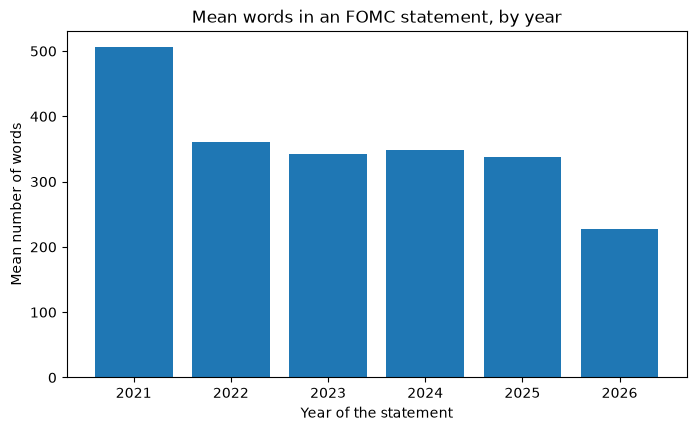

In [8]:
statements['words'] = statements['text'].str.split().str.len()
statements['year'] = pd.to_datetime(statements['date'], format='%Y-%m-%d').dt.year

# the mean word count of each year
by_year = statements.groupby('year')['words'].mean().round(1)
print(by_year)

# idxmax() gives the label of the highest value. int() turns it into a plain whole number.
ex4_year = int(by_year.idxmax())
ex4_mean = float(by_year.max())
print('Highest:', ex4_year, ex4_mean)

# \b on each side, so that uncertainty is not counted
ex4_uncertain = int(statements['text'].str.lower().str.contains(r'\buncertain\b').sum())
print('Statements with the word uncertain:', ex4_uncertain)
print('Statements with the letters uncertain:', statements['text'].str.lower().str.contains('uncertain').sum())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(by_year.index, by_year.values)
ax.set_title('Mean words in an FOMC statement, by year')
ax.set_xlabel('Year of the statement')
ax.set_ylabel('Mean number of words')
plt.show()

* 2021 has the highest mean, 505.5 words. The other years are between 228.0 and 361.1.
* 19 statements contain the whole word `uncertain`. Without `\b` the count is 32, because the pattern then also matches `uncertainty`.
* These are counts of words and of statements. They say nothing about what any statement means.

In [9]:
check('Exercise 4 year', ex4_year, 2021)
check('Exercise 4 mean words', ex4_mean, 505.5)
check('Exercise 4 uncertain', ex4_uncertain, 19)

Exercise 4 year: correct
Exercise 4 mean words: correct
Exercise 4 uncertain: correct


### Exercise 5

Exercises 5 to 8 use two short lists typed from rows of the course's synthetic holdings file. Run the next cell to create them: six bond descriptions in `more_descriptions`, and nine identifiers in `identifiers`, some of them damaged on purpose.

In [10]:
# six descriptions, typed by hand: ticker, coupon in percent, maturity as month/day/year
more_descriptions = [
    'KRIX 6.625 05/09/2033',
    'BEZL 6.125 04/09/2053',
    'ZEPN 5 08/16/2036',
    'GALX  9.25 06/17/2038',
    'TROE 4.375 12/26/2027',
    'LORE 8.625 06/09/2032',
]

# nine identifiers, typed by hand
identifiers = ['99087JAG1', '99039NAG1', '99138IAF4', '99088kah5', '99093PAA', '99114KAB6 ', '99053-BAG8', '99057FAC4', '99005FAA1']

print(f'Descriptions: {len(more_descriptions):,}   identifiers: {len(identifiers):,}')

Descriptions: 6   identifiers: 9


Q. Pull the coupon out of each of the six descriptions with a group, and turn it into a number. Store the list of six numbers, in the order of the descriptions, in **ex5_coupons**, and the highest coupon in **ex5_highest**. Look at the descriptions first: one coupon has no decimal point, and one line has two spaces.

In [11]:
# one or more spaces, then the coupon as a group with an optional decimal part, then one or more spaces
coupon_pattern = r'\s+(\d+(?:\.\d+)?)\s+'

ex5_coupons = []
for text in more_descriptions:
    match = re.search(coupon_pattern, text)
    # stop if a description has no coupon the pattern can read
    assert match is not None, f'no coupon found in: {text}'
    ex5_coupons.append(float(match.group(1)))

ex5_highest = max(ex5_coupons)

print(ex5_coupons)
print(f'Coupons read: {len(ex5_coupons):,} of {len(more_descriptions):,}   highest: {ex5_highest:.3f} percent')

[6.625, 6.125, 5.0, 9.25, 4.375, 8.625]
Coupons read: 6 of 6   highest: 9.250 percent


* The six coupons are 6.625, 6.125, 5.0, 9.25, 4.375, and 8.625 percent, and the highest is 9.25.
* `(?:\.\d+)?` makes the decimal part optional, so `5` is read as well as `6.625`. `\s+` on each side takes one space or two.
* The spaces on both sides are what keep the pattern off the digits of the maturity: in `05/09/2033` no run of digits has a space on each side.
* In Excel, `=VALUE(INDEX(TEXTSPLIT(TRIM(A2), " "), 1, 2))` gives the coupon of the description in A2 as a number.

In [12]:
check('Exercise 5 coupons', ex5_coupons, [6.625, 6.125, 5.0, 9.25, 4.375, 8.625])
check('Exercise 5 highest coupon', ex5_highest, 9.25)

Exercise 5 coupons: correct
Exercise 5 highest coupon: correct


### Exercise 6

Q. Pull the maturity out of each of the six descriptions as text, and turn the six into dates with `pd.to_datetime()` and `format='%m/%d/%Y'`. Store the year of the latest maturity in **ex6_latest_year** and the number of bonds that mature after 2030-12-31 in **ex6_after_2030**.

In [13]:
# two digits, a slash, two digits, a slash, four digits, at the end of the text
maturity_pattern = r'\d{2}/\d{2}/\d{4}$'

maturity_text = []
for text in more_descriptions:
    match = re.search(maturity_pattern, text)
    # stop if a description has no maturity the pattern can read
    assert match is not None, f'no maturity found in: {text}'
    maturity_text.append(match.group(0))
print(maturity_text)

# text into dates. The format says month/day/year.
maturities = pd.Series(pd.to_datetime(maturity_text, format='%m/%d/%Y'))

ex6_latest_year = int(maturities.max().year)
ex6_after_2030 = int((maturities > pd.Timestamp('2030-12-31')).sum())

print(f'Latest maturity: {maturities.max().date()}   year: {ex6_latest_year}')
print(f'Maturing after 2030-12-31: {ex6_after_2030:,} of {len(maturities):,}')

['05/09/2033', '04/09/2053', '08/16/2036', '06/17/2038', '12/26/2027', '06/09/2032']
Latest maturity: 2053-04-09   year: 2053
Maturing after 2030-12-31: 5 of 6


* The latest maturity is 2053-04-09, so the year is 2053. 5 of the 6 bonds mature after 2030-12-31. The one that does not matures on 2027-12-26.
* The pattern only finds the text. `pd.to_datetime()` is what makes it a date, and it would raise an error on a month of 13, which the pattern would accept.
* In Excel, `=TEXTAFTER(A2, " ", -1)` returns the text after the last space, which is the maturity. `TEXTAFTER` is in Microsoft 365 and Excel 2024.

In [14]:
check('Exercise 6 latest year', ex6_latest_year, 2053)
check('Exercise 6 maturing after 2030', ex6_after_2030, 5)

Exercise 6 latest year: correct
Exercise 6 maturing after 2030: correct


### Exercise 7

Q. Test each of the nine values in `identifiers` against the shape of a CUSIP: nine characters, each a digit or a capital letter. Store the number that have the shape in **ex7_valid**, and the list of those that do not, in the order of the list, in **ex7_failed**. Print the failures with `repr()`.

In [15]:
# nine characters, each a digit or a capital letter
cusip_shape = r'[0-9A-Z]{9}'

# fullmatch() tests the whole value, so a space at the end fails
ex7_failed = [value for value in identifiers if re.fullmatch(cusip_shape, value) is None]
ex7_valid = len(identifiers) - len(ex7_failed)

print(f'With the shape: {ex7_valid:,} of {len(identifiers):,}')
for value in ex7_failed:
    print(f'Fails: {repr(value)}   characters: {len(value)}')

# the same test on a column, with pandas
print(pd.Series(identifiers).str.fullmatch(cusip_shape).sum())

With the shape: 5 of 9
Fails: '99088kah5'   characters: 9
Fails: '99093PAA'   characters: 8
Fails: '99114KAB6 '   characters: 10
Fails: '99053-BAG8'   characters: 10
5


* 5 of the 9 values have the shape, and 4 do not.
* The four failures: `99088kah5` has letters in lower case, `99093PAA` has eight characters, the third has a space at the end, which `repr()` shows inside the quotes, and `99053-BAG8` has a hyphen.
* `re.search()` with the same pattern and no anchors would pass the value with the space at the end and count 6. `fullmatch()` is the right function for a whole value.
* In Excel for Microsoft 365, `=REGEXTEST(A2, "^[0-9A-Z]{9}$")` is the same test.

In [16]:
check('Exercise 7 with the shape', ex7_valid, 5)
check('Exercise 7 failures', ex7_failed, ['99088kah5', '99093PAA', '99114KAB6 ', '99053-BAG8'])

Exercise 7 with the shape: correct
Exercise 7 failures: correct


### Exercise 8

Q. Write a function `parse_description(text)` that **returns** a dictionary with three keys: `'ticker'` as text, `'coupon'` as a number, and `'maturity'` as the text of the date, as typed. It must read a coupon with no decimal point and a line with two spaces. The check cell calls your function on three descriptions.

In [17]:
def parse_description(text):
    """Return a dictionary with the ticker, the coupon as a number, and the maturity text of one bond description."""
    match = re.fullmatch(r'([A-Z]+)\s+(\d+(?:\.\d+)?)\s+(\d{2}/\d{2}/\d{4})', text)
    # a description that cannot be read is an error, and the message says which one
    if match is None:
        raise ValueError(f'cannot read this description: {text}')
    return {'ticker': match.group(1), 'coupon': float(match.group(2)), 'maturity': match.group(3)}


# the function on every description, as a table
parsed = pd.DataFrame([parse_description(text) for text in more_descriptions])
print(parsed)

# a check that matters is an assert: one row for each description
assert len(parsed) == len(more_descriptions), 'a description was lost'
print(f'Parsed: {len(parsed):,} of {len(more_descriptions):,}   mean coupon: {parsed["coupon"].mean():.3f} percent')

# a description the function cannot read raises an error, which try and except report
try:
    parse_description('krix 6.625 05/09/33')
except ValueError as error:
    print('ValueError:', error)

  ticker  coupon    maturity
0   KRIX   6.625  05/09/2033
1   BEZL   6.125  04/09/2053
2   ZEPN   5.000  08/16/2036
3   GALX   9.250  06/17/2038
4   TROE   4.375  12/26/2027
5   LORE   8.625  06/09/2032
Parsed: 6 of 6   mean coupon: 6.667 percent
ValueError: cannot read this description: krix 6.625 05/09/33


* The function returns one dictionary for each description, and a list of dictionaries makes a table: 6 rows, with a mean coupon of 6.667 percent.
* `KRIX 6.625 05/09/2033` gives the ticker `KRIX`, the coupon 6.625, and the maturity text `05/09/2033`. `ZEPN 5 08/16/2036` gives a coupon of 5.0, and the `GALX` line with two spaces is read too.
* A description it cannot read, here a ticker in lower case and a two-digit year, raises a `ValueError` with the text in the message. Returning nothing would let a bad line pass unseen.
* The function returns its answer, so it can be called on one description, on a list, or by the check cell.

In [18]:
check('Exercise 8 plain description', parse_description('KRIX 6.625 05/09/2033'), {'ticker': 'KRIX', 'coupon': 6.625, 'maturity': '05/09/2033'})
check('Exercise 8 whole-number coupon', parse_description('ZEPN 5 08/16/2036'), {'ticker': 'ZEPN', 'coupon': 5.0, 'maturity': '08/16/2036'})
check('Exercise 8 two spaces', parse_description('GALX  9.25 06/17/2038'), {'ticker': 'GALX', 'coupon': 9.25, 'maturity': '06/17/2038'})

Exercise 8 plain description: correct
Exercise 8 whole-number coupon: correct
Exercise 8 two spaces: correct


### Exercise 9: AI check

You ask an AI assistant to pull the range out of every statement and say how many statements have one. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. How many statements should have a range? The lesson worked it out. Then run the code. Does the answer agree with you?

* The lesson found a range in every one of the 46 statements. The original code reported 6, with no error and no warning.
* The bug was the pattern `\d+ to \d+ percent`. It allows only digits on each side of `to`, so it cannot match a figure with a slash or a hyphen in it, such as `5-1/4 to 5-1/2 percent`. Most statements write the range that way, and the pattern silently skipped them.
* The 6 matches it did return are worse than a miss. They read `4 to 1 percent`, `4 to 4 percent`, and `4 to 5 percent`. None of those is a range in a statement. Each is the tail of one figure and the start of the next: `3/4 to 1 percent`, `3-3/4 to 4 percent`, `4-3/4 to 5 percent`.
* The fix is the class from the lesson, with the slash and both hyphens: `[\d/\u2011-]+`. The check was the count: 46 statements, so 46 expected.

In [19]:
# a figure may hold digits, slashes, and either kind of hyphen
pattern = r'[\d/\u2011-]+ to [\d/\u2011-]+ percent'

found = statements['text'].str.findall(pattern)

# the number of statements with at least one match
ex9_statements = int((found.str.len() > 0).sum())

# the range in the first statement
ex9_first = found.iloc[0][0]

print('Statements with a range:', ex9_statements)
print('Range in the statement dated', statements['date'].iloc[0] + ':', ex9_first)

Statements with a range: 46
Range in the statement dated 2021-01-27: 0 to 1/4 percent


In [20]:
check('Exercise 9 statements with a range', ex9_statements, 46)
check('Exercise 9 first range', ex9_first, '0 to 1/4 percent')

Exercise 9 statements with a range: correct
Exercise 9 first range: correct
